In [115]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels
import re
from sklearn.preprocessing import MinMaxScaler, LabelEncoder, OneHotEncoder
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression
from sklearn import metrics
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report, f1_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import train_test_split

from catboost import CatBoostClassifier
#!pip install lightgbm
import lightgbm as lgb
from lightgbm import LGBMClassifier
from sklearn.metrics import mean_squared_error
from sklearn.metrics import roc_auc_score
import pandas.core.algorithms as algos
import scipy.stats.stats as stats
import traceback
import string
#!pip install scorecardpy
import scorecardpy as sc
import mlxtend
from sklearn.tree import DecisionTreeClassifier
#!pip install xgboost
from xgboost import XGBClassifier

In [116]:
df = pd.read_csv('amex_data/train.csv')
print(df.shape)
df.head()

(45528, 19)


,customer_id,name,age,gender,owns_car,owns_house,no_of_children,net_yearly_income,no_of_days_employed,occupation_type,total_family_members,migrant_worker,yearly_debt_payments,credit_limit,credit_limit_used(%),credit_score,prev_defaults,default_in_last_6months,credit_card_default
0,CST_115179,ita Bose,46,F,N,Y,0.0,107934.04,612.0,Unknown,1.0,1.0,33070.28,18690.93,73,544.0,2,1,1
1,CST_121920,Alper Jonathan,29,M,N,Y,0.0,109862.62,2771.0,Laborers,2.0,0.0,15329.53,37745.19,52,857.0,0,0,0
2,CST_109330,Umesh Desai,37,M,N,Y,0.0,230153.17,204.0,Laborers,2.0,0.0,48416.60,41598.36,43,650.0,0,0,0
3,CST_128288,Rie,39,F,N,Y,0.0,122325.82,11941.0,Core staff,2.0,0.0,22574.36,32627.76,20,754.0,0,0,0
4,CST_151355,McCool,46,M,Y,Y,0.0,387286.00,1459.0,Core staff,1.0,0.0,38282.95,52950.64,75,927.0,0,0,0


EDA

In [117]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45528 entries, 0 to 45527
Data columns (total 19 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   customer_id              45528 non-null  object 
 1   name                     45528 non-null  object 
 2   age                      45528 non-null  int64  
 3   gender                   45528 non-null  object 
 4   owns_car                 44981 non-null  object 
 5   owns_house               45528 non-null  object 
 6   no_of_children           44754 non-null  float64
 7   net_yearly_income        45528 non-null  float64
 8   no_of_days_employed      45065 non-null  float64
 9   occupation_type          45528 non-null  object 
 10  total_family_members     45445 non-null  float64
 11  migrant_worker           45441 non-null  float64
 12  yearly_debt_payments     45433 non-null  float64
 13  credit_limit             45528 non-null  float64
 14  credit_limit_used(%)  

In [118]:
df["credit_card_default"].value_counts()#(normalize=True)

credit_card_default
0    41831
1     3697
Name: count, dtype: int64

In [119]:
df["credit_card_default"].value_counts(normalize=True)

credit_card_default
0    0.918797
1    0.081203
Name: proportion, dtype: float64

In [120]:
# check for duplicates
df.duplicated().sum()

np.int64(0)

In [121]:
# check for nulls
df.isnull().sum().sort_values(ascending=False).head(10)

no_of_children             774
owns_car                   547
no_of_days_employed        463
yearly_debt_payments        95
migrant_worker              87
total_family_members        83
credit_score                 8
customer_id                  0
default_in_last_6months      0
prev_defaults                0
dtype: int64

In [122]:
cat_feats = ['customer_id', 'name', 'gender', 'owns_car', 'owns_house', 'occupation_type']
num_feats = ['age',
 'no_of_children',
 'net_yearly_income',
 'no_of_days_employed',
 'total_family_members',
 'migrant_worker',
 'yearly_debt_payments',
 'credit_limit',
 'credit_limit_used(%)',
 'credit_score',
 'prev_defaults',
 'default_in_last_6months',
 'credit_card_default']

In [123]:
for i in cat_feats:
    print("Column Name:",i)
    print(df[i].value_counts(normalize=True))
    print("\n")

Column Name: customer_id
customer_id
CST_115179    0.000022
CST_115723    0.000022
CST_156690    0.000022
CST_136647    0.000022
CST_120077    0.000022
                ...   
CST_150394    0.000022
CST_105778    0.000022
CST_135083    0.000022
CST_126760    0.000022
CST_160078    0.000022
Name: proportion, Length: 45528, dtype: float64


Column Name: name
name
Jonathan            0.004547
Jonathan Stempel    0.004217
David               0.003734
Stempel             0.003624
Jessica             0.003558
                      ...   
Hui                 0.000022
Jeffrey Heller      0.000022
Coelho              0.000022
Xize                0.000022
Mostafavi           0.000022
Name: proportion, Length: 4010, dtype: float64


Column Name: gender
gender
F      0.657991
M      0.341987
XNA    0.000022
Name: proportion, dtype: float64


Column Name: owns_car
owns_car
N    0.661235
Y    0.338765
Name: proportion, dtype: float64


Column Name: owns_house
owns_house
Y    0.695001
N    0.304999
Na

In [124]:
# df[df['gender'] == 'XNA']
df['gender'] = df['gender'].apply(lambda x: 'M' if x=='XNA' else x)
df['gender'].value_counts()

gender
F    29957
M    15571
Name: count, dtype: int64

In [125]:
# fill owns_car with mode of the data
df['owns_car'] = df['owns_car'].fillna(df['owns_car'].mode()[0])
df["owns_car"].value_counts()

owns_car
N    30290
Y    15238
Name: count, dtype: int64

In [126]:
df[cat_feats].isnull().sum()

customer_id        0
name               0
gender             0
owns_car           0
owns_house         0
occupation_type    0
dtype: int64

In [127]:
df[num_feats].isnull().sum().sort_values(ascending=False).head(10)

no_of_children          774
no_of_days_employed     463
yearly_debt_payments     95
migrant_worker           87
total_family_members     83
credit_score              8
age                       0
net_yearly_income         0
credit_limit              0
credit_limit_used(%)      0
dtype: int64

In [128]:
# full 'no_of_days_employed' nulls with median based on 'occupation_type'
occp_days_employed = df.groupby(by='occupation_type')['no_of_days_employed'].median()

for i in occp_days_employed.index:
    df['no_of_days_employed'] = np.where((df['no_of_days_employed'].isna()) & (df['occupation_type'] == i), occp_days_employed[i], df['no_of_days_employed'])

In [129]:
# fill 'yearly_debt_payments' nulls with median based on 'credit_card_default'
yearDebt_credit = df.groupby(by='credit_card_default')['yearly_debt_payments'].median()

for i in yearDebt_credit.index:
    df['yearly_debt_payments'] = np.where((df['yearly_debt_payments'].isna()) & (df['credit_card_default'] == i), yearDebt_credit[i], df['yearly_debt_payments'])

In [130]:
# fill 'credit_card_default' nulls with median based on 'credit_score'

cred_score = df.groupby(by='credit_card_default')['credit_score'].median()

for i in cred_score.index:
    df['credit_score'] = np.where((df['credit_score'].isna()) & (df['credit_card_default'] == i), cred_score[i], df['credit_score'])


In [131]:
# fill other cat feats with modes

# df['migrant_worker'].mode() # 0

df['migrant_worker'] = df['migrant_worker'].fillna(df['migrant_worker'].mode()[0])
df['total_family_members'] = df['total_family_members'].fillna(df['total_family_members'].mode()[0])
df['no_of_children'] = df['no_of_children'].fillna(df['no_of_children'].mode()[0])

In [132]:
df.isnull().sum()

customer_id                0
name                       0
age                        0
gender                     0
owns_car                   0
owns_house                 0
no_of_children             0
net_yearly_income          0
no_of_days_employed        0
occupation_type            0
total_family_members       0
migrant_worker             0
yearly_debt_payments       0
credit_limit               0
credit_limit_used(%)       0
credit_score               0
prev_defaults              0
default_in_last_6months    0
credit_card_default        0
dtype: int64

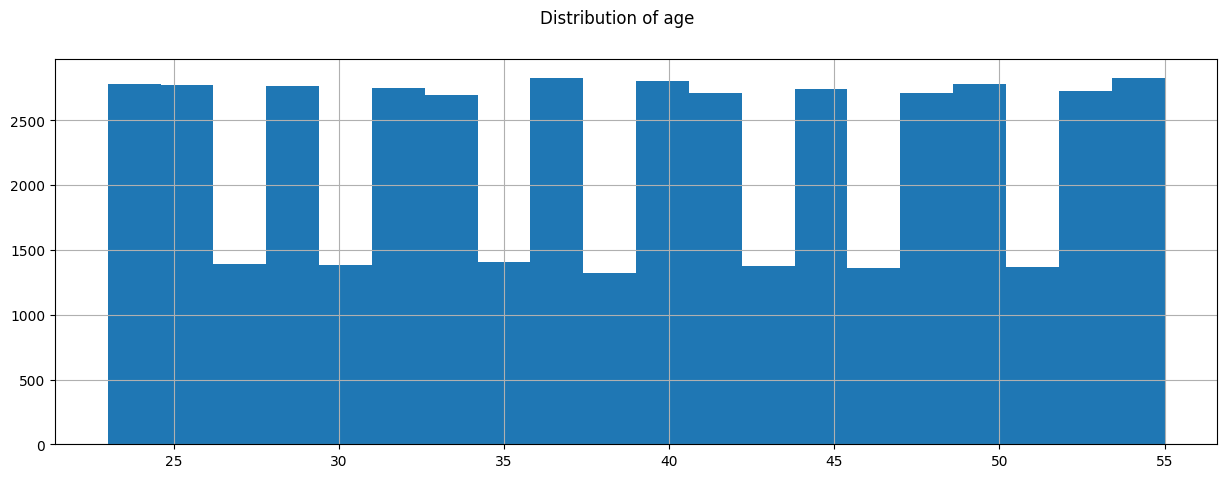

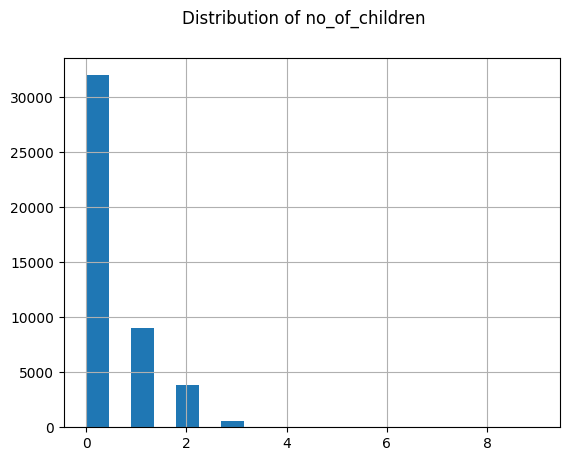

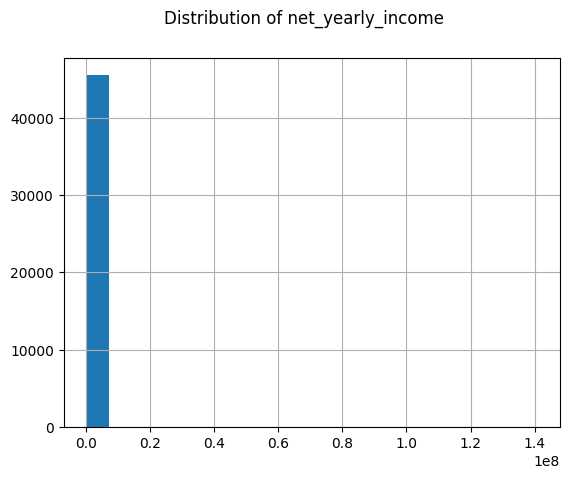

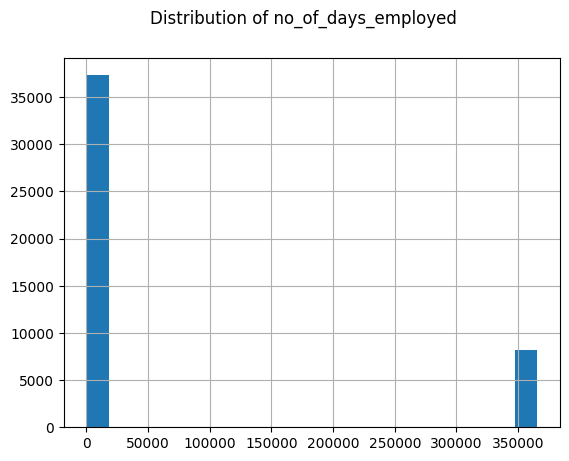

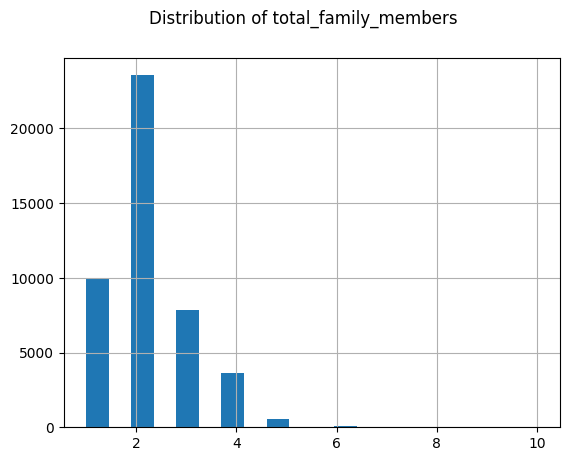

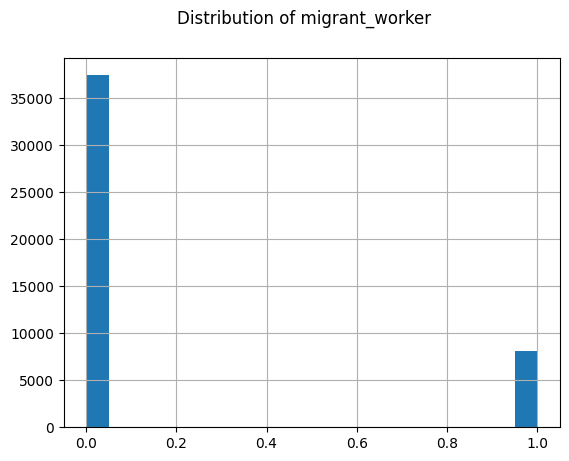

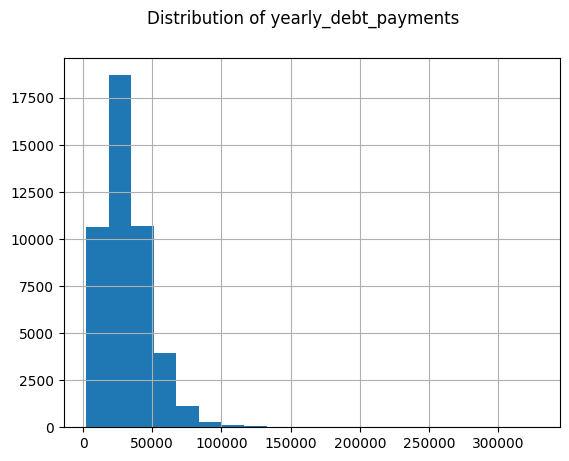

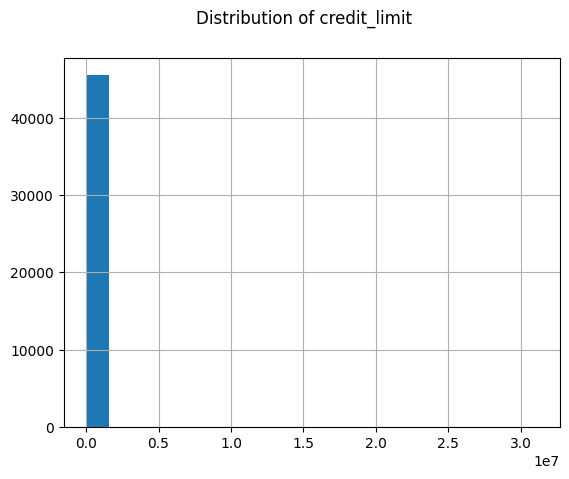

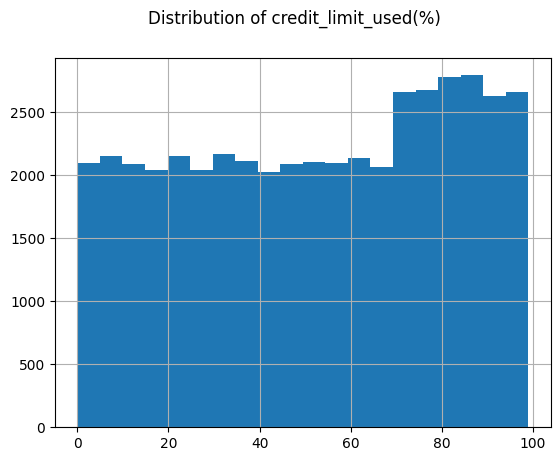

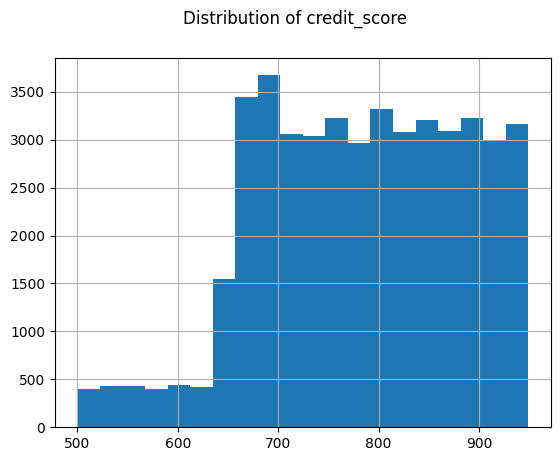

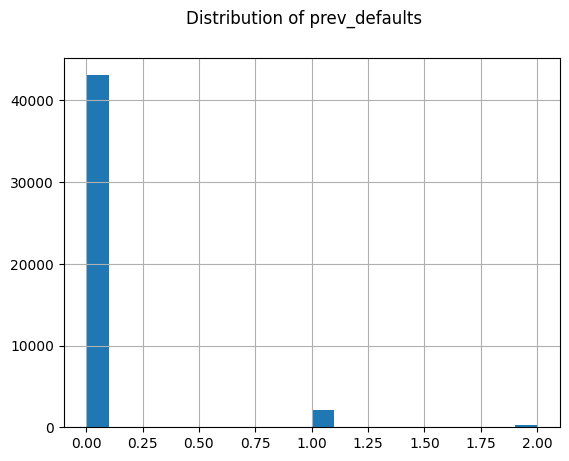

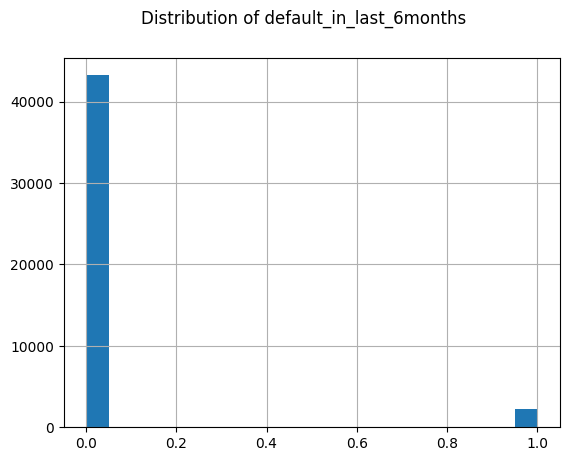

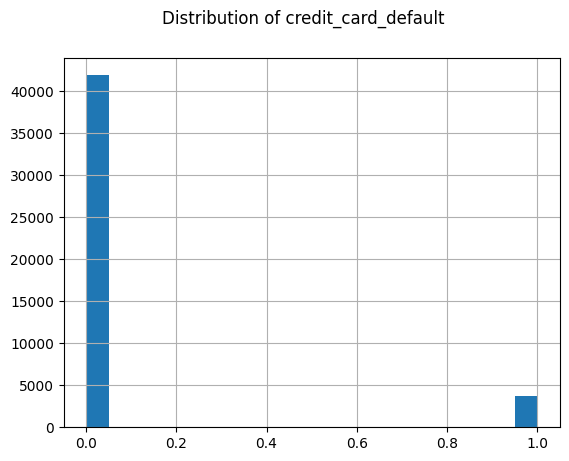

In [133]:
plt.figure(figsize=(15,5))

for feat in num_feats:
    df[feat].hist(bins=20) # bins=20
    plt.suptitle(f"Distribution of {feat}")
    plt.show()

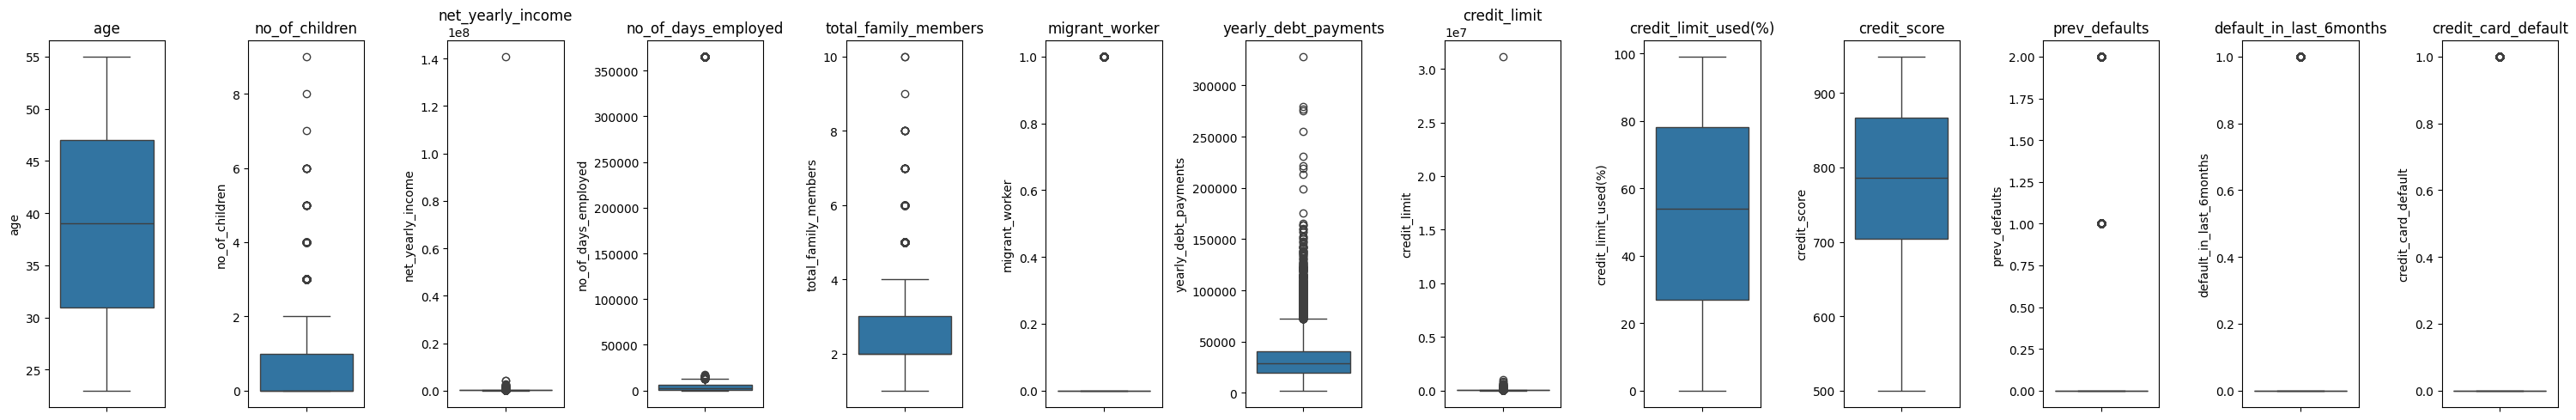

In [134]:
plt.figure(figsize=(30,5))

for i, feat in enumerate(num_feats):
    plt.subplot(1, len(num_feats), i+1)
    sns.boxplot(y=df[feat])
    plt.title(feat)

plt.tight_layout()
plt.show()

In [135]:
# plt.figure(figsize=(15,10))

# for i, feat in enumerate(cat_feats):
#     plt.subplot(3, len(cat_feats), i+1)
#     sns.countplot(data=df, x=feat, order=df[feat].value_counts().index, palette="Set2")
#     plt.title(f"Distribution of {feat}")
#     plt.xticks(rotation=45)

# plt.tight_layout()
# plt.show()

<Axes: >

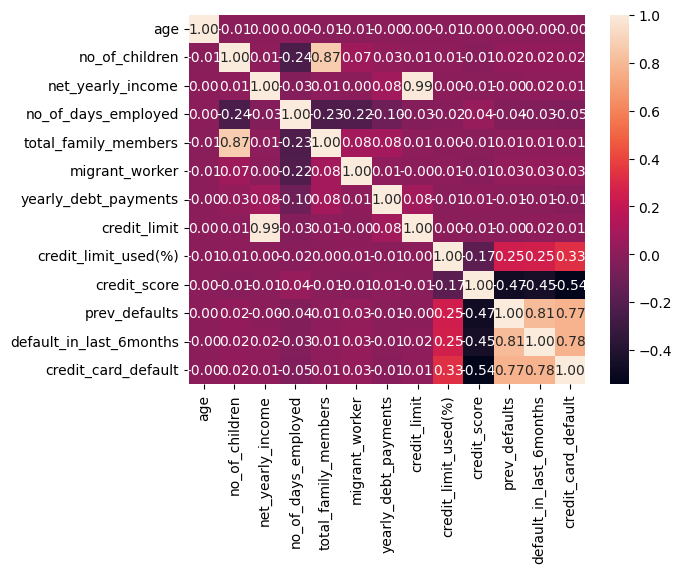

In [136]:
corr = df[num_feats].corr()
sns.heatmap(corr, annot=True, fmt=".2f")

# correlations between credit defaults

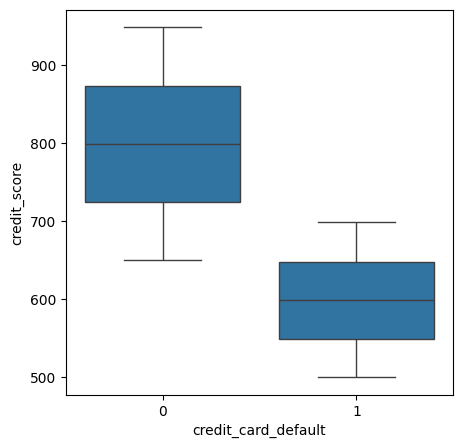

In [137]:
plt.figure(figsize=[5,5])
sns.boxplot(data=df, x='credit_card_default', y='credit_score')
plt.show()

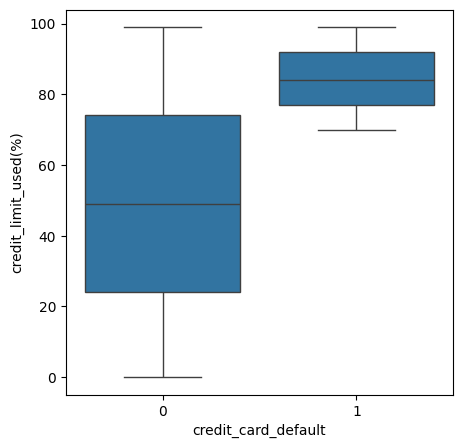

In [138]:
plt.figure(figsize=[5,5])
sns.boxplot(data=df, x='credit_card_default', y='credit_limit_used(%)')
plt.show()

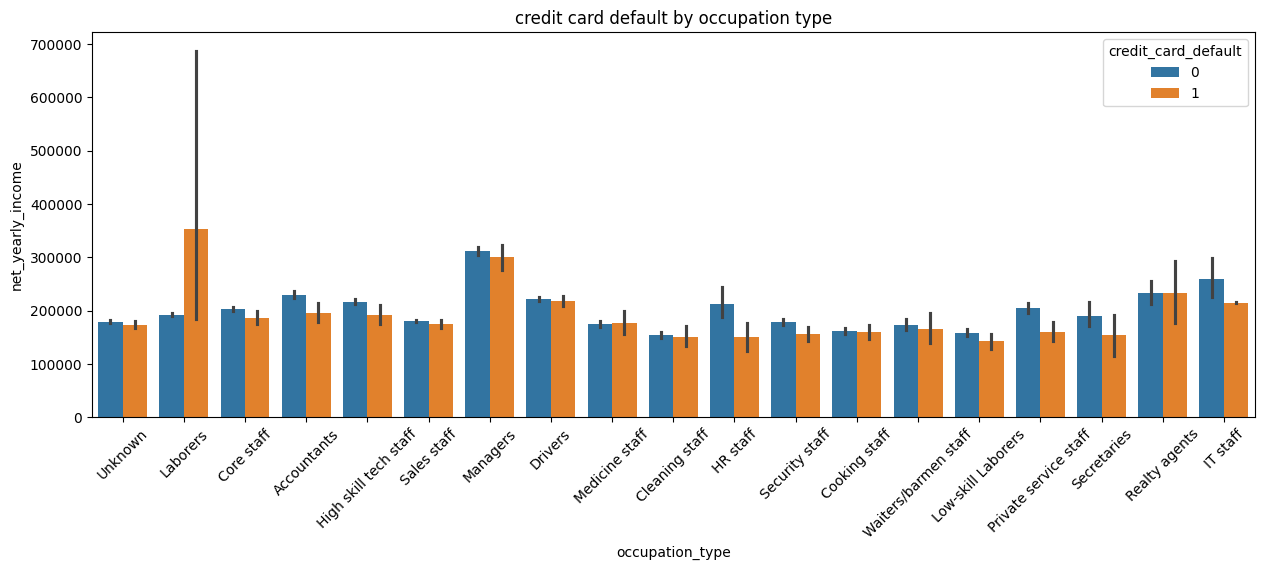

In [139]:
plt.figure(figsize=[15,5])
sns.barplot(data=df, x='occupation_type', y='net_yearly_income', hue='credit_card_default')
plt.xticks(rotation=45)
plt.title('credit card default by occupation type')
plt.show()

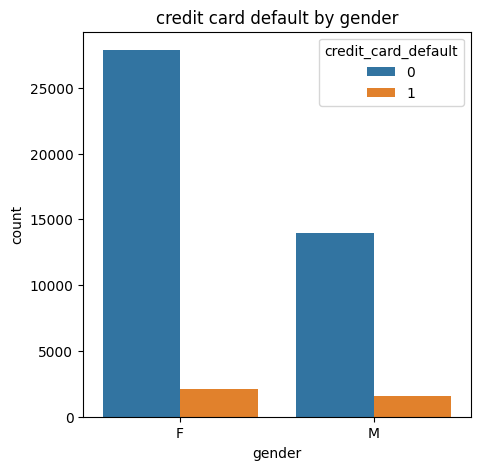

In [140]:
plt.figure(figsize=[5,5])
sns.countplot(data=df, x='gender', hue='credit_card_default')
plt.title('credit card default by gender')
plt.show()

In [141]:
# plt.figure(figsize=(30,30))

# sns.scatterplot(df, x="age", y="credit_card_default", hue="gender", alpha=0.7) #size="net_yearly_income",
# plt.title("Credit score vs. age, colored by gender, sized by credit limit")

Feature Selection

In [142]:
# drop feats with IV < 0.02: Unpredictive / Not useful for modeling

max_bin = 20
force_bin = 3

# define a binning function
def mono_bin(Y, X, n = max_bin):
    
    df1 = pd.DataFrame({"X": X, "Y": Y})
    justmiss = df1[['X','Y']][df1.X.isnull()]
    notmiss = df1[['X','Y']][df1.X.notnull()]
    r = 0
    while np.abs(r) < 1:
        try:
            d1 = pd.DataFrame({"X": notmiss.X, "Y": notmiss.Y, "Bucket": pd.qcut(notmiss.X, n)})
            d2 = d1.groupby('Bucket', as_index=True)
            r, p = stats.spearmanr(d2.mean().X, d2.mean().Y)
            n = n - 1 
        except Exception as e:
            n = n - 1

    if len(d2) == 1:
        n = force_bin         
        # bins = algos.quantile(X, np.linspace(0, 1, force_bins))
        # bins = X.quantile(np.linspace(0, 1, force_bins)).values

        # bins = algos.quantile(notmiss.X, np.linspace(0, 1, n))
        bins = notmiss.X.quantile(np.linspace(0, 1, n)).values
        if len(np.unique(bins)) == 2:
            bins = np.insert(bins, 0, 1)
            bins[1] = bins[1]-(bins[1]/2)
        d1 = pd.DataFrame({"X": notmiss.X, "Y": notmiss.Y, "Bucket": pd.cut(notmiss.X, np.unique(bins),include_lowest=True)}) 
        d2 = d1.groupby('Bucket', as_index=True)
    
    d3 = pd.DataFrame({},index=[])
    d3["MIN_VALUE"] = d2.min().X
    d3["MAX_VALUE"] = d2.max().X
    d3["COUNT"] = d2.count().Y
    d3["EVENT"] = d2.sum().Y
    d3["NONEVENT"] = d2.count().Y - d2.sum().Y
    d3=d3.reset_index(drop=True)
    
    if len(justmiss.index) > 0:
        d4 = pd.DataFrame({'MIN_VALUE':np.nan},index=[0])
        d4["MAX_VALUE"] = np.nan
        d4["COUNT"] = justmiss.count().Y
        d4["EVENT"] = justmiss.sum().Y
        d4["NONEVENT"] = justmiss.count().Y - justmiss.sum().Y
        d3 = d3.append(d4,ignore_index=True)
    
    d3["EVENT_RATE"] = d3.EVENT/d3.COUNT
    d3["NON_EVENT_RATE"] = d3.NONEVENT/d3.COUNT
    d3["DIST_EVENT"] = d3.EVENT/d3.sum().EVENT
    d3["DIST_NON_EVENT"] = d3.NONEVENT/d3.sum().NONEVENT
    d3["WOE"] = np.log(d3.DIST_EVENT/d3.DIST_NON_EVENT)
    d3["IV"] = (d3.DIST_EVENT-d3.DIST_NON_EVENT)*np.log(d3.DIST_EVENT/d3.DIST_NON_EVENT)
    d3["VAR_NAME"] = "VAR"
    d3 = d3[['VAR_NAME','MIN_VALUE', 'MAX_VALUE', 'COUNT', 'EVENT', 'EVENT_RATE', 'NONEVENT', 'NON_EVENT_RATE', 'DIST_EVENT','DIST_NON_EVENT','WOE', 'IV']]       
    d3 = d3.replace([np.inf, -np.inf], 0)
    d3.IV = d3.IV.sum()
    
    return(d3)

def char_bin(Y, X):
        
    df1 = pd.DataFrame({"X": X, "Y": Y})
    justmiss = df1[['X','Y']][df1.X.isnull()]
    notmiss = df1[['X','Y']][df1.X.notnull()]    
    df2 = notmiss.groupby('X',as_index=True)
    
    d3 = pd.DataFrame({},index=[])
    d3["COUNT"] = df2.count().Y
    d3["MIN_VALUE"] = df2.sum().Y.index
    d3["MAX_VALUE"] = d3["MIN_VALUE"]
    d3["EVENT"] = df2.sum().Y
    d3["NONEVENT"] = df2.count().Y - df2.sum().Y
    
    if len(justmiss.index) > 0:
        d4 = pd.DataFrame({'MIN_VALUE':np.nan},index=[0])
        d4["MAX_VALUE"] = np.nan
        d4["COUNT"] = justmiss.count().Y
        d4["EVENT"] = justmiss.sum().Y
        d4["NONEVENT"] = justmiss.count().Y - justmiss.sum().Y
        d3 = pd.concat([d3, d4], ignore_index=True)
    
    d3["EVENT_RATE"] = d3.EVENT/d3.COUNT
    d3["NON_EVENT_RATE"] = d3.NONEVENT/d3.COUNT
    d3["DIST_EVENT"] = d3.EVENT/d3.sum().EVENT
    d3["DIST_NON_EVENT"] = d3.NONEVENT/d3.sum().NONEVENT
    d3["WOE"] = np.log(d3.DIST_EVENT/d3.DIST_NON_EVENT)
    d3["IV"] = (d3.DIST_EVENT-d3.DIST_NON_EVENT)*np.log(d3.DIST_EVENT/d3.DIST_NON_EVENT)
    d3["VAR_NAME"] = "VAR"
    d3 = d3[['VAR_NAME','MIN_VALUE', 'MAX_VALUE', 'COUNT', 'EVENT', 'EVENT_RATE', 'NONEVENT', 'NON_EVENT_RATE', 'DIST_EVENT','DIST_NON_EVENT','WOE', 'IV']]      
    d3 = d3.replace([np.inf, -np.inf], 0)
    d3.IV = d3.IV.sum()
    d3 = d3.reset_index(drop=True)
    
    return(d3)

def data_vars(df1, target):
    
    stack = traceback.extract_stack()
    filename, lineno, function_name, code = stack[-2]
    vars_name = re.compile(r'\((.*?)\).*$').search(code).groups()[0]
    final = (re.findall(r"[\w']+", vars_name))[-1]
    
    x = df1.dtypes.index
    count = -1
    
    for i in x:
        if i.upper() not in (final.upper()):
            if np.issubdtype(df1[i], np.number) and len(pd.Series.unique(df1[i])) > 2:
                conv = mono_bin(target, df1[i])
                conv["VAR_NAME"] = i
                count = count + 1
            else:
                conv = char_bin(target, df1[i])
                conv["VAR_NAME"] = i            
                count = count + 1
                
            if count == 0:
                iv_df = conv
            else:
                iv_df = pd.concat([iv_df, conv], ignore_index=True)
    
    iv = pd.DataFrame({'IV':iv_df.groupby('VAR_NAME').IV.max()})
    iv = iv.reset_index()
    return(iv_df,iv) 

In [143]:
final_iv, IV = data_vars(df.drop(columns =["customer_id", "name", 'credit_card_default']), df["credit_card_default"])
final_iv

/var/folders/nk/kfrl4_s124900b5mzmt1xfyc0000gp/T/ipykernel_70107/87996675.py:16: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  d2 = d1.groupby('Bucket', as_index=True)
/var/folders/nk/kfrl4_s124900b5mzmt1xfyc0000gp/T/ipykernel_70107/87996675.py:17: DeprecationWarning: Please import `spearmanr` from the `scipy.stats` namespace; the `scipy.stats.stats` namespace is deprecated and will be removed in SciPy 2.0.0.
  r, p = stats.spearmanr(d2.mean().X, d2.mean().Y)
/var/folders/nk/kfrl4_s124900b5mzmt1xfyc0000gp/T/ipykernel_70107/87996675.py:16: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  d2 = d1.groupby('Bucket',

,VAR_NAME,MIN_VALUE,MAX_VALUE,COUNT,EVENT,EVENT_RATE,NONEVENT,NON_EVENT_RATE,DIST_EVENT,DIST_NON_EVENT,WOE,IV
0,age,23,39,23454,1904,0.081180,21550,0.918820,0.515012,0.515168,-0.000303,9.743859e-08
1,age,40,55,22074,1793,0.081227,20281,0.918773,0.484988,0.484832,0.000322,9.743859e-08
2,gender,F,F,29957,2093,0.069867,27864,0.930133,0.566135,0.666109,-0.162621,4.244305e-02
3,gender,M,M,15571,1604,0.103012,13967,0.896988,0.433865,0.333891,0.261919,4.244305e-02
4,owns_car,N,N,30290,2560,0.084516,27730,0.915484,0.692453,0.662906,0.043608,3.999149e-03
5,owns_car,Y,Y,15238,1137,0.074616,14101,0.925384,0.307547,0.337094,-0.091736,3.999149e-03
6,owns_house,N,N,13886,1143,0.082313,12743,0.917687,0.309170,0.304631,0.014790,9.686010e-05
7,owns_house,Y,Y,31642,2554,0.080716,29088,0.919284,0.690830,0.695369,-0.006549,9.686010e-05
8,no_of_children,0.0,1.0,41000,3292,0.080293,37708,0.919707,0.890452,0.901437,-0.012261,1.295438e-03
9,no_of_children,2.0,9.0,4528,405,0.089443,4123,0.910557,0.109548,0.098563,0.105667,1.295438e-03


In [144]:
IV.sort_values('IV')

,VAR_NAME,IV
0,age,9.743859e-08
15,yearly_debt_payments,5.211574e-05
12,owns_house,9.686010e-05
1,credit_limit,7.497421e-04
8,no_of_children,1.295438e-03
11,owns_car,3.999149e-03
14,total_family_members,4.351803e-03
13,prev_defaults,6.681591e-03
7,net_yearly_income,7.126441e-03
6,migrant_worker,1.435505e-02


In [145]:
low_IV_cols = list(IV[IV.IV<0.02]['VAR_NAME'])
low_IV_cols

['age',
 'credit_limit',
 'migrant_worker',
 'net_yearly_income',
 'no_of_children',
 'owns_car',
 'owns_house',
 'prev_defaults',
 'total_family_members',
 'yearly_debt_payments']

In [146]:
# drop low IV columns (< 0.02)
df_orig = df.copy()

df = df.drop(columns=low_IV_cols)
df = df.drop(columns=["customer_id", "name"])
df.head(1)

,gender,no_of_days_employed,occupation_type,credit_limit_used(%),credit_score,default_in_last_6months,credit_card_default
0,F,612.0,Unknown,73,544.0,1,1


/Users/areiling/.pyenv/versions/3.9.6/lib/python3.9/site-packages/scorecardpy/condition_fun.py:40: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  datetime_cols = dat.apply(pd.to_numeric,errors='ignore').select_dtypes(object).apply(pd.to_datetime,errors='ignore').select_dtypes('datetime64').columns.tolist()
/Users/areiling/.pyenv/versions/3.9.6/lib/python3.9/site-packages/scorecardpy/condition_fun.py:40: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_datetime without passing `errors` and catch exceptions explicitly instead
  datetime_cols = dat.apply(pd.to_numeric,errors='ignore').select_dtypes(object).apply(pd.to_datetime,errors='ignore').select_dtypes('datetime64').columns.tolist()
/Users/areiling/.pyenv/versions/3.9.6/lib/python3.9/site-packages/scorecardpy/condition_fun.py:40: UserWarning: Could not infer format, so each element

[INFO] creating woe binning ...


/Users/areiling/.pyenv/versions/3.9.6/lib/python3.9/site-packages/scorecardpy/woebin.py:320: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  init_bin = dtm.groupby('bin', group_keys=False)['y'].agg([n0, n1])\
/Users/areiling/.pyenv/versions/3.9.6/lib/python3.9/site-packages/scorecardpy/woebin.py:320: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  init_bin = dtm.groupby('bin', group_keys=False)['y'].agg([n0, n1])\
/Users/areiling/.pyenv/versions/3.9.6/lib/python3.9/site-packages/scorecardpy/woebin.py:361: FutureWarning: The provided callable <built-in function sum> is currently using SeriesGroupBy.sum. In a futur

{'default_in_last_6months': <Figure size 640x480 with 2 Axes>,
 'credit_score': <Figure size 640x480 with 2 Axes>,
 'credit_limit_used(%)': <Figure size 640x480 with 2 Axes>,
 'no_of_days_employed': <Figure size 640x480 with 2 Axes>,
 'occupation_type': <Figure size 640x480 with 2 Axes>,
 'gender': <Figure size 640x480 with 2 Axes>}

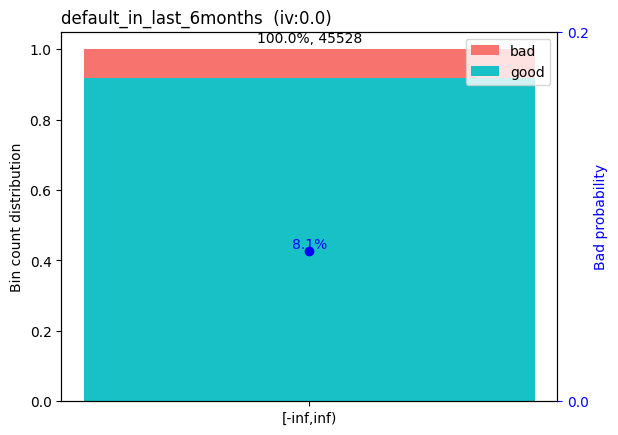

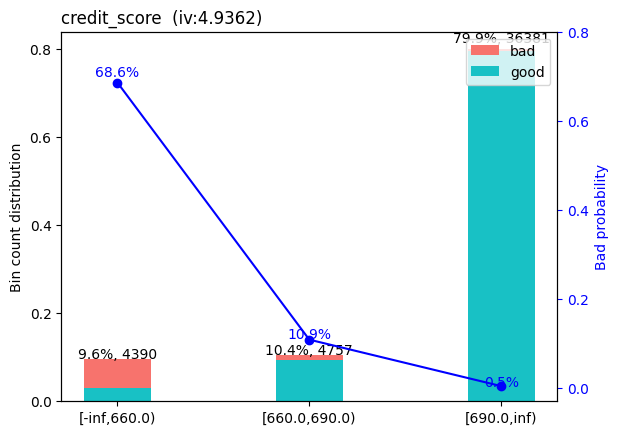

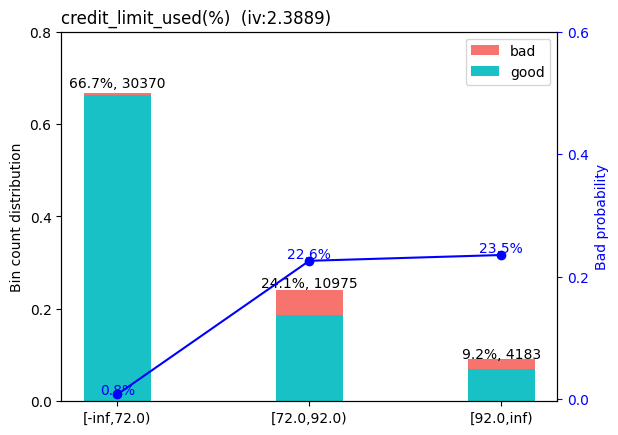

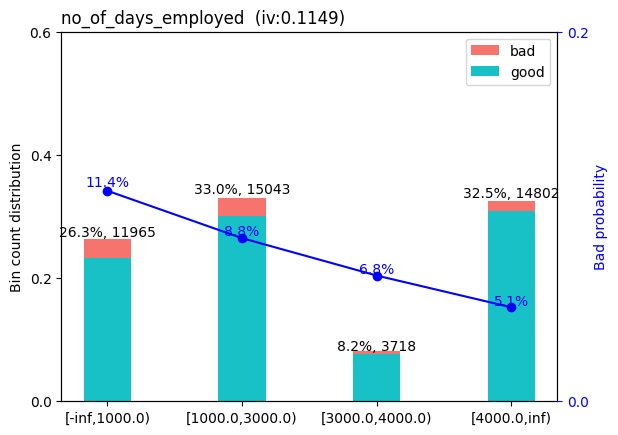

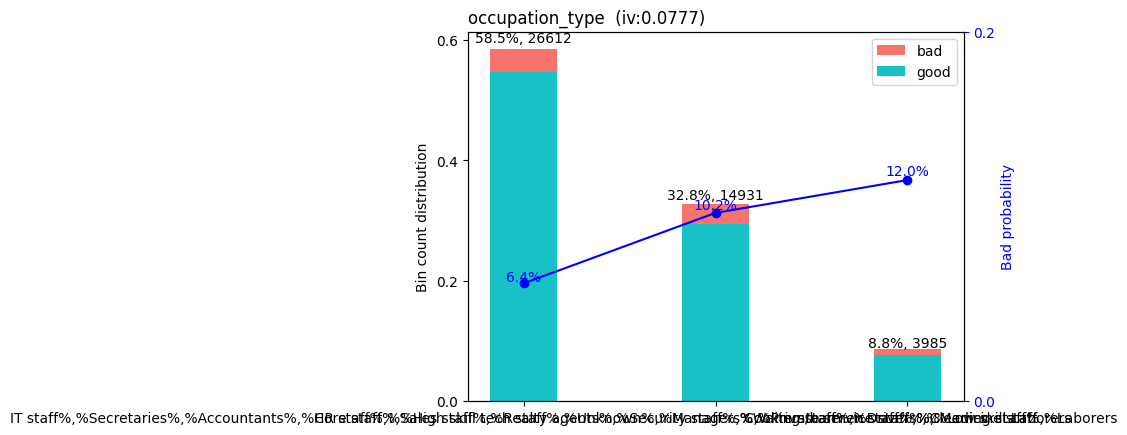

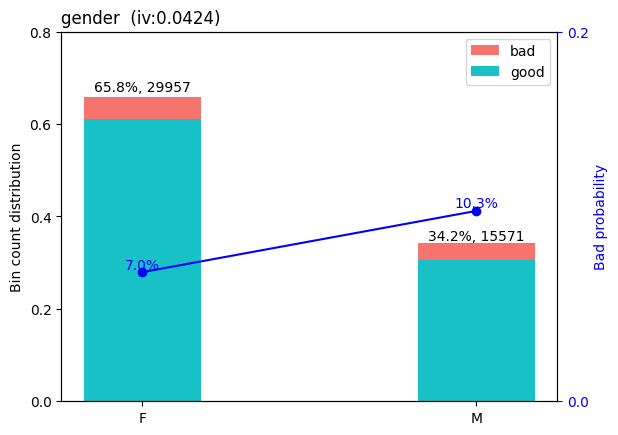

In [147]:
# woe binning
bins = sc.woebin(df, y="credit_card_default")
sc.woebin_plot(bins)

In [148]:
# converting into woe values
train_woe = sc.woebin_ply(df, bins)
train_woe.head(10)

[INFO] converting into woe values ...


,credit_card_default,default_in_last_6months_woe,credit_score_woe,credit_limit_used(%)_woe,no_of_days_employed_woe,occupation_type_woe,gender_woe
0,1,0.0,3.207030,1.193855,0.374762,-0.259863,-0.162621
1,0,0.0,-2.947093,-2.427741,0.091300,0.250215,0.261919
2,0,0.0,3.207030,-2.427741,0.374762,0.250215,0.261919
3,0,0.0,-2.947093,-2.427741,-0.500125,-0.259863,-0.162621
4,0,0.0,-2.947093,1.193855,0.091300,-0.259863,0.261919
5,0,0.0,-2.947093,-2.427741,0.091300,-0.259863,-0.162621
6,0,0.0,-2.947093,-2.427741,-0.500125,-0.259863,0.261919
7,0,0.0,-2.947093,1.193855,0.091300,-0.259863,-0.162621
8,0,0.0,-2.947093,-2.427741,-0.500125,0.250215,-0.162621
9,0,0.0,0.324009,-2.427741,0.091300,-0.259863,-0.162621


Encoding

In [149]:
df["gender"] = df["gender"].apply(lambda x : 1 if x == "F" else 0)
#df["owns_car"] = df["owns_car"].apply(lambda x : 1 if x == "Y" else 0)
#df["owns_house"] = df["owns_house"].apply(lambda x : 1 if x == "Y" else 0)

occupation_type_encoded_df = pd.get_dummies(df["occupation_type"], prefix= "occupation")
df = pd.concat([df, occupation_type_encoded_df], axis=1)
df.drop(columns=["occupation_type"], inplace=True)
df.head()

,gender,no_of_days_employed,credit_limit_used(%),credit_score,default_in_last_6months,credit_card_default,occupation_Accountants,occupation_Cleaning staff,occupation_Cooking staff,occupation_Core staff,...,occupation_Low-skill Laborers,occupation_Managers,occupation_Medicine staff,occupation_Private service staff,occupation_Realty agents,occupation_Sales staff,occupation_Secretaries,occupation_Security staff,occupation_Unknown,occupation_Waiters/barmen staff
0,1,612.0,73,544.0,1,1,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False
1,0,2771.0,52,857.0,0,0,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,0,204.0,43,650.0,0,0,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,1,11941.0,20,754.0,0,0,False,False,False,True,...,False,False,False,False,False,False,False,False,False,False
4,0,1459.0,75,927.0,0,0,False,False,False,True,...,False,False,False,False,False,False,False,False,False,False


Train test split

In [150]:
X = df.drop(['credit_card_default'], axis=1)
y = df['credit_card_default']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y, random_state=42)

print(f"X_train: {X_train.shape}")
print(f"X_test: {X_test.shape}")

print(f"y_train: {y_train.shape}")
print(f"y_test: {y_test.shape}")

X_train: (31869, 24)
X_test: (13659, 24)
y_train: (31869,)
y_test: (13659,)


In [151]:
X_woe = train_woe.drop(['credit_card_default'], axis=1)
y_woe = train_woe['credit_card_default']

X_train_woe, X_test_woe, y_train_woe, y_test_woe = train_test_split(X_woe, y_woe, test_size=0.3, stratify=y_woe, random_state=42)

print(f"X_train_woe: {X_train_woe.shape}")
print(f"X_test_woe: {X_test_woe.shape}")

print(f"y_train_woe: {y_train_woe.shape}")
print(f"y_test_woe: {y_test_woe.shape}")

X_train_woe: (31869, 6)
X_test_woe: (13659, 6)
y_train_woe: (31869,)
y_test_woe: (13659,)


Standardize / Scaling

In [152]:
scaler = MinMaxScaler()

cols = X_train.columns

X_train[cols] = scaler.fit_transform(X_train[cols])
X_test[cols] = scaler.transform(X_test[cols])

Handle imbalanced data with SMOTE

In [153]:
sm = SMOTE(random_state=42)

X_train,y_train = sm.fit_resample(X_train,y_train)

print(f"X_train_sm: {X_train.shape}")
print(f"y_train_sm: {y_train.shape}")

X_train = pd.DataFrame(data=X_train, columns=cols)
y_train = pd.Series(y_train)
print(f"X_train: {X_train.shape}")
print(f"y_train: {y_train.shape}")

X_train.head(1)

X_train_sm: (58562, 24)
y_train_sm: (58562,)
X_train: (58562, 24)
y_train: (58562,)


/Users/areiling/.pyenv/versions/3.9.6/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


,gender,no_of_days_employed,credit_limit_used(%),credit_score,default_in_last_6months,occupation_Accountants,occupation_Cleaning staff,occupation_Cooking staff,occupation_Core staff,occupation_Drivers,...,occupation_Low-skill Laborers,occupation_Managers,occupation_Medicine staff,occupation_Private service staff,occupation_Realty agents,occupation_Sales staff,occupation_Secretaries,occupation_Security staff,occupation_Unknown,occupation_Waiters/barmen staff
0,1.0,0.002021,0.090909,0.4098,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [154]:
# confirm class balance
y_train.value_counts()

credit_card_default
0    29281
1    29281
Name: count, dtype: int64

Model 1 - Logit Regression

In [155]:
from statsmodels.discrete.discrete_model import Logit

logit = Logit(y_train, X_train)
logit_fit = logit.fit()

logit_fit.summary()

         Current function value: 0.095180
         Iterations: 35


/Users/areiling/.pyenv/versions/3.9.6/lib/python3.9/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


<class 'statsmodels.iolib.summary.Summary'>
"""
                            Logit Regression Results                           
===============================================================================
Dep. Variable:     credit_card_default   No. Observations:                58562
Model:                           Logit   Df Residuals:                    58538
Method:                            MLE   Df Model:                           23
Date:                 Tue, 31 Mar 2026   Pseudo R-squ.:                  0.8627
Time:                         21:09:57   Log-Likelihood:                -5573.9
converged:                       False   LL-Null:                       -40592.
Covariance Type:             nonrobust   LLR p-value:                     0.000
====================================================================================================
                                       coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------------
gender                              -0.4158      0.058     -7.178      0.000      -0.529      -0.302
no_of_days_employed                 -0.5604      0.097     -5.755      0.000      -0.751      -0.370
credit_limit_used(%)                 9.4506      0.183     51.605      0.000       9.092       9.810
credit_score                       -26.6346      0.518    -51.400      0.000     -27.650     -25.619
default_in_last_6months            961.7431   6432.730      0.150      0.881   -1.16e+04    1.36e+04
occupation_Accountants               3.5739      0.261     13.673      0.000       3.062       4.086
occupation_Cleaning staff            3.1044      0.314      9.892      0.000       2.489       3.720
occupation_Cooking staff             4.9029      0.268     18.273      0.000       4.377       5.429
occupation_Core staff                3.9271      0.239     16.460      0.000       3.460       4.395
occupation_Drivers                   3.9577      0.236     16.750      0.000       3.495       4.421
occupation_HR staff                  1.0717      0.977      1.096      0.273      -0.844       2.988
occupation_High skill tech staff     3.9334      0.256     15.360      0.000       3.431       4.435
occupation_IT staff                -11.8036    359.903     -0.033      0.974    -717.201     693.594
occupation_Laborers                  4.0511      0.226     17.920      0.000       3.608       4.494
occupation_Low-skill Laborers        3.3915      0.332     10.218      0.000       2.741       4.042
occupation_Managers                  3.8525      0.238     16.205      0.000       3.387       4.318
occupation_Medicine staff            4.0186      0.270     14.892      0.000       3.490       4.547
occupation_Private service staff     2.8025      0.362      7.739      0.000       2.093       3.512
occupation_Realty agents             3.8629      0.535      7.216      0.000       2.814       4.912
occupation_Sales staff               4.0337      0.236     17.075      0.000       3.571       4.497
occupation_Secretaries               2.6185      0.530      4.936      0.000       1.579       3.658
occupation_Security staff            4.3094      0.266     16.213      0.000       3.788       4.830
occupation_Unknown                   3.6266      0.233     15.596      0.000       3.171       4.082
occupation_Waiters/barmen staff      4.2257      0.379     11.138      0.000       3.482       4.969
====================================================================================================

Possibly complete quasi-separation: A fraction 0.62 of observations can be
perfectly predicted. This might indicate that there is complete
quasi-separation. In this case some parameters will not be identified.
"""

Model 2 - Logistic Regression

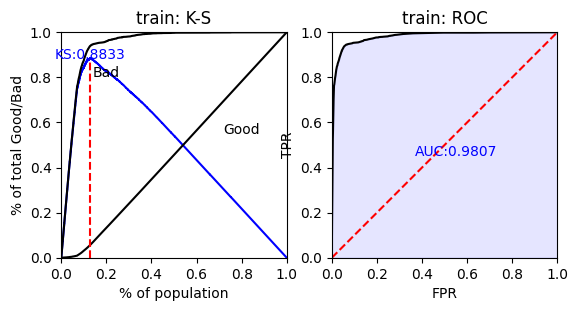

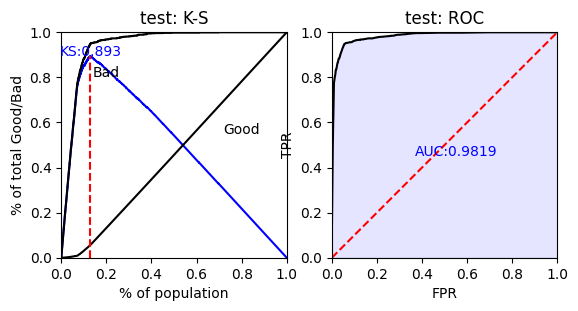

/Users/areiling/.pyenv/versions/3.9.6/lib/python3.9/site-packages/scorecardpy/scorecard.py:353: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dat_score.loc[:,'score'] = card_basepoints + dat_score.sum(axis=1)


In [156]:
lr = LogisticRegression(penalty='l1', C=0.9, solver='saga', n_jobs=-1)
lr.fit(X_train_woe, y_train_woe)
# lr.coef_
# lr.intercept_

# predicted probas
train_pred = lr.predict_proba(X_train_woe)[:,1]
test_pred = lr.predict_proba(X_test_woe)[:,1]

train_perf = sc.perf_eva(y_train_woe, train_pred, title = "train")
test_perf = sc.perf_eva(y_test_woe, test_pred, title = "test")

card = sc.scorecard(bins, lr, X_train_woe.columns)
# credit score
score = sc.scorecard_ply(df_orig, card, only_total_score=False, print_step=0, replace_blank_na=True, var_kp = None)

Evaluate Models

In [218]:
def eval_model(model):
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    print("--------------------------------------")
    
    print(confusion_matrix(y_train, y_train_pred))
    print(classification_report(y_train, y_train_pred))
    print("Accuracy of TRAIN data:", 100*accuracy_score(y_train, y_train_pred))
    print("F1_Score of TRAIN data:", 100*f1_score(y_train, y_train_pred, average="macro"))
    print("--------------------------------------")
    
    print(confusion_matrix(y_test, y_test_pred))
    print(classification_report(y_test, y_test_pred))
    print("Accuracy of TEST data:", 100*accuracy_score(y_test, y_test_pred))
    print("F1_Score of TEST data:", 100*f1_score(y_test, y_test_pred, average="macro"))
    print("--------------------------------------")
    
    # calculate the RMSE
    rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
    print("RMSE: ", rmse)
    
    # calculate ROC AUC
    roc_auc = roc_auc_score(y_test, y_test_pred, average=None)
    print("ROC AUC score: ", roc_auc)

    return roc_auc

In [185]:
roc_aucs = {}

In [196]:
lr = LogisticRegression()
lr.fit(X_train, y_train)

LogisticRegression()

In [186]:
lr_roc_auc = eval_model(lr)
roc_aucs['Logistic Regression'] = lr_roc_auc

--------------------------------------
[[27769  1512]
 [  998 28283]]
              precision    recall  f1-score   support

           0       0.97      0.95      0.96     29281
           1       0.95      0.97      0.96     29281

    accuracy                           0.96     58562
   macro avg       0.96      0.96      0.96     58562
weighted avg       0.96      0.96      0.96     58562

Accuracy of TRAIN data: 95.71394419589495
F1_Score of TRAIN data: 95.71361398932014
--------------------------------------
[[11947   603]
 [   44  1065]]
              precision    recall  f1-score   support

           0       1.00      0.95      0.97     12550
           1       0.64      0.96      0.77      1109

    accuracy                           0.95     13659
   macro avg       0.82      0.96      0.87     13659
weighted avg       0.97      0.95      0.96     13659

Accuracy of TEST data: 95.26319642726408
F1_Score of TEST data: 87.03253601444817
--------------------------------------
R

In [219]:
# logistic regression feature importance
feat_names = X.columns
coefficients = lr.coef_[0]

feat_imps = pd.DataFrame({
    'Feature': feat_names,
    'Importance': np.abs(coefficients)
})

feat_imps = feat_imps.sort_values(by='Importance', ascending=False)


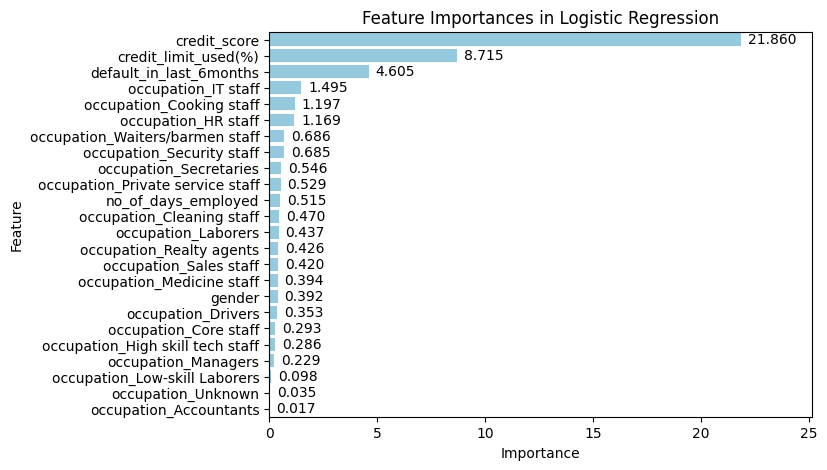

In [222]:
# plt.figure(figsize=(10, 6))
# plt.bar(=feat_imps['Feature'], height=feat_imps['Importance'])
# plt.xticks(rotation=90)
# plt.xlabel('Feature')
# plt.ylabel('Absolute Coefficient Value (Importance)')
# plt.title('Feature Importances in Logistic Regression')
# plt.tight_layout()
# plt.show()

fig, ax = plt.subplots(figsize=(7, 5))

sns.barplot(data=feat_imps, x='Importance', y='Feature', color='skyblue')

for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', padding=5)

plt.title('Feature Importances in Logistic Regression')
plt.margins(x=0.15)
# plt.tight_layout()
plt.show()


In [160]:
dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)

DecisionTreeClassifier()

In [187]:
dt_roc_auc = eval_model(dt)
roc_aucs['Decision Tree Classifier'] = dt_roc_auc

--------------------------------------
[[29281     0]
 [    1 29280]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     29281
           1       1.00      1.00      1.00     29281

    accuracy                           1.00     58562
   macro avg       1.00      1.00      1.00     58562
weighted avg       1.00      1.00      1.00     58562

Accuracy of TRAIN data: 99.99829240804617
F1_Score of TRAIN data: 99.99829240804567
--------------------------------------
[[12269   281]
 [  147   962]]
              precision    recall  f1-score   support

           0       0.99      0.98      0.98     12550
           1       0.77      0.87      0.82      1109

    accuracy                           0.97     13659
   macro avg       0.88      0.92      0.90     13659
weighted avg       0.97      0.97      0.97     13659

Accuracy of TEST data: 96.86653488542353
F1_Score of TEST data: 90.04419479880393
--------------------------------------
R

In [161]:
rfc = RandomForestClassifier(random_state=42, oob_score=True)
rfc.fit(X_train, y_train)

RandomForestClassifier(oob_score=True, random_state=42)

In [188]:
rfc_roc_auc = eval_model(rfc)
roc_aucs['Random Forest Classifier'] = rfc_roc_auc

--------------------------------------
[[29280     1]
 [    0 29281]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     29281
           1       1.00      1.00      1.00     29281

    accuracy                           1.00     58562
   macro avg       1.00      1.00      1.00     58562
weighted avg       1.00      1.00      1.00     58562

Accuracy of TRAIN data: 99.99829240804617
F1_Score of TRAIN data: 99.99829240804567
--------------------------------------
[[12244   306]
 [  105  1004]]
              precision    recall  f1-score   support

           0       0.99      0.98      0.98     12550
           1       0.77      0.91      0.83      1109

    accuracy                           0.97     13659
   macro avg       0.88      0.94      0.91     13659
weighted avg       0.97      0.97      0.97     13659

Accuracy of TEST data: 96.99099494838568
F1_Score of TEST data: 90.679419679814
--------------------------------------
RMS

In [162]:
cbc = CatBoostClassifier(random_seed=42)
cbc.fit(X_train, y_train)

Learning rate set to 0.058574
0:	learn: 0.5176698	total: 60.6ms	remaining: 1m
1:	learn: 0.3895170	total: 64.6ms	remaining: 32.2s
2:	learn: 0.2982838	total: 68.2ms	remaining: 22.7s
3:	learn: 0.2360360	total: 71.6ms	remaining: 17.8s
4:	learn: 0.1900808	total: 75.1ms	remaining: 14.9s
5:	learn: 0.1594506	total: 78.5ms	remaining: 13s
6:	learn: 0.1353111	total: 81.8ms	remaining: 11.6s
7:	learn: 0.1200222	total: 85.1ms	remaining: 10.5s
8:	learn: 0.1076652	total: 88.8ms	remaining: 9.78s
9:	learn: 0.0997928	total: 92.6ms	remaining: 9.17s
10:	learn: 0.0932882	total: 96.6ms	remaining: 8.68s
11:	learn: 0.0883876	total: 101ms	remaining: 8.31s
12:	learn: 0.0836651	total: 105ms	remaining: 7.94s
13:	learn: 0.0799076	total: 108ms	remaining: 7.6s
14:	learn: 0.0772278	total: 111ms	remaining: 7.31s
15:	learn: 0.0754971	total: 115ms	remaining: 7.06s
16:	learn: 0.0735593	total: 118ms	remaining: 6.83s
17:	learn: 0.0724780	total: 121ms	remaining: 6.62s
18:	learn: 0.0715584	total: 125ms	remaining: 6.44s
19:	le

CatBoostClassifier(random_seed=42)

In [189]:
cbc_roc_auc = eval_model(cbc)
roc_aucs['Cat Boost Classifier'] = cbc_roc_auc

--------------------------------------
[[28935   346]
 [   68 29213]]
              precision    recall  f1-score   support

           0       1.00      0.99      0.99     29281
           1       0.99      1.00      0.99     29281

    accuracy                           0.99     58562
   macro avg       0.99      0.99      0.99     58562
weighted avg       0.99      0.99      0.99     58562

Accuracy of TRAIN data: 99.29305693111574
F1_Score of TRAIN data: 99.29304099978626
--------------------------------------
[[12291   259]
 [  126   983]]
              precision    recall  f1-score   support

           0       0.99      0.98      0.98     12550
           1       0.79      0.89      0.84      1109

    accuracy                           0.97     13659
   macro avg       0.89      0.93      0.91     13659
weighted avg       0.97      0.97      0.97     13659

Accuracy of TEST data: 97.18134563291602
F1_Score of TEST data: 91.04097715236772
--------------------------------------
R

In [163]:
xgb = XGBClassifier(random_seed=42)
xgb.fit(X_train, y_train)

/Users/areiling/.pyenv/versions/3.9.6/lib/python3.9/site-packages/xgboost/core.py:158: UserWarning: [21:13:27] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "random_seed" } are not used.

  warnings.warn(smsg, UserWarning)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, random_seed=42, ...)

In [190]:
xgb_roc_auc = eval_model(xgb)
roc_aucs['XGBoost Classifier'] = xgb_roc_auc

--------------------------------------
[[28930   351]
 [   77 29204]]
              precision    recall  f1-score   support

           0       1.00      0.99      0.99     29281
           1       0.99      1.00      0.99     29281

    accuracy                           0.99     58562
   macro avg       0.99      0.99      0.99     58562
weighted avg       0.99      0.99      0.99     58562

Accuracy of TRAIN data: 99.26915064376217
F1_Score of TRAIN data: 99.26913464425147
--------------------------------------
[[12248   302]
 [  128   981]]
              precision    recall  f1-score   support

           0       0.99      0.98      0.98     12550
           1       0.76      0.88      0.82      1109

    accuracy                           0.97     13659
   macro avg       0.88      0.93      0.90     13659
weighted avg       0.97      0.97      0.97     13659

Accuracy of TEST data: 96.85189252507504
F1_Score of TEST data: 90.14915252827298
--------------------------------------
R

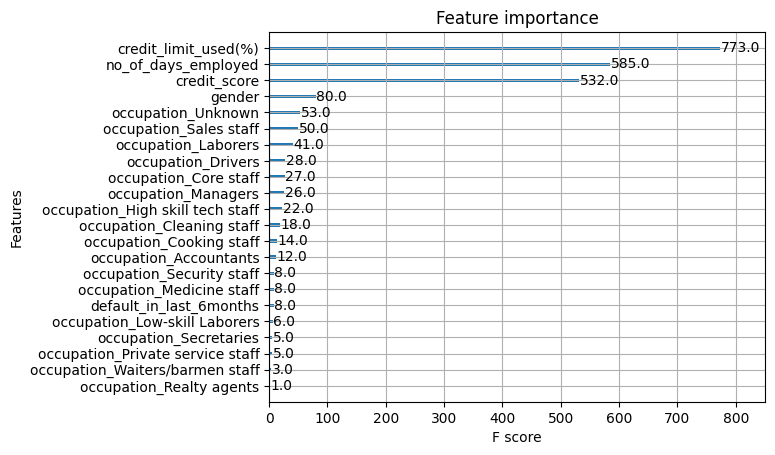

<Figure size 640x480 with 0 Axes>

In [166]:
from xgboost import plot_importance

# xgb.feature_importances_

plot_importance(xgb)
plt.show()
plt.savefig("XGB - feature importance")

In [167]:
lgbm = LGBMClassifier(random_state=42)
lgbm.fit(X_train, y_train)

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 29281, number of negative: 29281
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002229 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 899
[LightGBM] [Info] Number of data points in the train set: 58562, number of used features: 24
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000


LGBMClassifier(random_state=42)

In [191]:
lgbm_roc_auc = eval_model(lgbm)
roc_aucs['LGBM Classifier'] = lgbm_roc_auc

--------------------------------------
[[28758   523]
 [  112 29169]]
              precision    recall  f1-score   support

           0       1.00      0.98      0.99     29281
           1       0.98      1.00      0.99     29281

    accuracy                           0.99     58562
   macro avg       0.99      0.99      0.99     58562
weighted avg       0.99      0.99      0.99     58562

Accuracy of TRAIN data: 98.91567910932004
F1_Score of TRAIN data: 98.9156256982769
--------------------------------------
[[12239   311]
 [  119   990]]
              precision    recall  f1-score   support

           0       0.99      0.98      0.98     12550
           1       0.76      0.89      0.82      1109

    accuracy                           0.97     13659
   macro avg       0.88      0.93      0.90     13659
weighted avg       0.97      0.97      0.97     13659

Accuracy of TEST data: 96.85189252507504
F1_Score of TEST data: 90.21566168479256
--------------------------------------
RM

In [168]:
error_rate = []

for i in range(1,40):
    knn = KNeighborsClassifier(n_neighbors=i)
    knn.fit(X_train, y_train)
    pred_i = knn.predict(X_test)
    error_rate.append(np.mean(pred_i != y_test))

In [170]:
# error_rate

Text(0, 0.5, 'Error Rate')

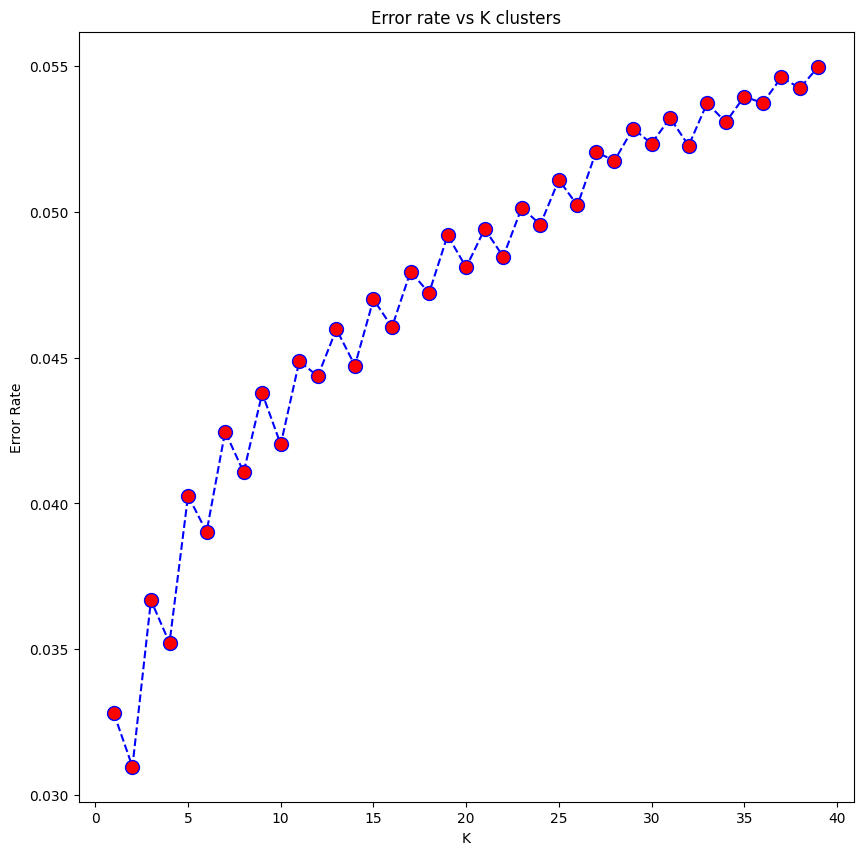

In [171]:
plt.figure(figsize=[10,10])
plt.plot(range(1,40), error_rate, color='blue', linestyle='dashed',
          marker='o', markerfacecolor='red', markersize=10)
plt.title('Error rate vs K clusters')
plt.xlabel('K')
plt.ylabel('Error Rate')

# lowest error rate at K=2

In [172]:
knn = KNeighborsClassifier(n_neighbors = 2)
knn.fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=2)

In [192]:
knn_roc_auc = eval_model(knn)
roc_aucs['KNN'] = knn_roc_auc

--------------------------------------
[[29281     0]
 [  328 28953]]
              precision    recall  f1-score   support

           0       0.99      1.00      0.99     29281
           1       1.00      0.99      0.99     29281

    accuracy                           0.99     58562
   macro avg       0.99      0.99      0.99     58562
weighted avg       0.99      0.99      0.99     58562

Accuracy of TRAIN data: 99.43990983914483
F1_Score of TRAIN data: 99.43989226850995
--------------------------------------
[[12266   284]
 [  139   970]]
              precision    recall  f1-score   support

           0       0.99      0.98      0.98     12550
           1       0.77      0.87      0.82      1109

    accuracy                           0.97     13659
   macro avg       0.88      0.93      0.90     13659
weighted avg       0.97      0.97      0.97     13659

Accuracy of TEST data: 96.90314078629476
F1_Score of TEST data: 90.2019877845293
--------------------------------------
RM

In [193]:
roc_aucs

{'Logistic Regression': np.float64(0.9561384040034631),
 'Decision Tree Classifier': np.float64(0.9225288566204074),
 'Random Forest Classifier': np.float64(0.9404688190430344),
 'Cat Boost Classifier': np.float64(0.9328733398237528),
 'XGBoost Classifier': np.float64(0.9302584791582094),
 'LGBM Classifier': np.float64(0.9339576230694895),
 'KNN': np.float64(0.9260161877287962)}

In [207]:
roc_aucs_df = pd.DataFrame(list(roc_aucs.items()), columns=['model', 'roc_auc_score'])
roc_aucs_df = roc_aucs_df.sort_values(by='roc_auc_score', ascending=False)

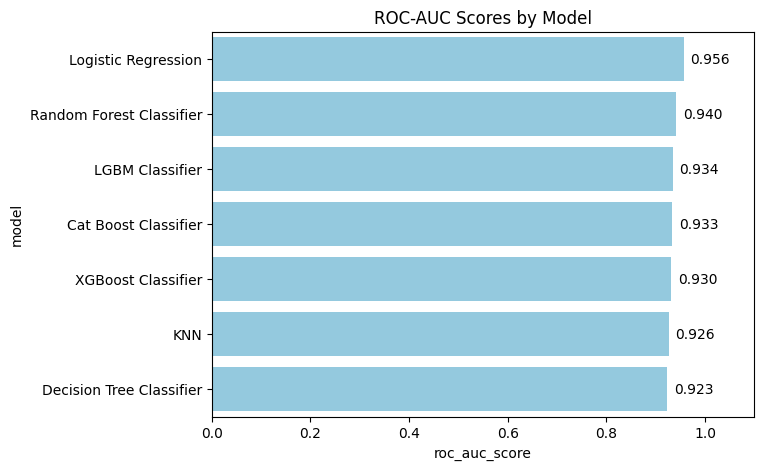

In [216]:
fig, ax = plt.subplots(figsize=(7, 5))

sns.barplot(data=roc_aucs_df, x='roc_auc_score', y='model', color='skyblue')

for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', padding=5)

plt.title('ROC-AUC Scores by Model')
plt.margins(x=0.15)
plt.show()

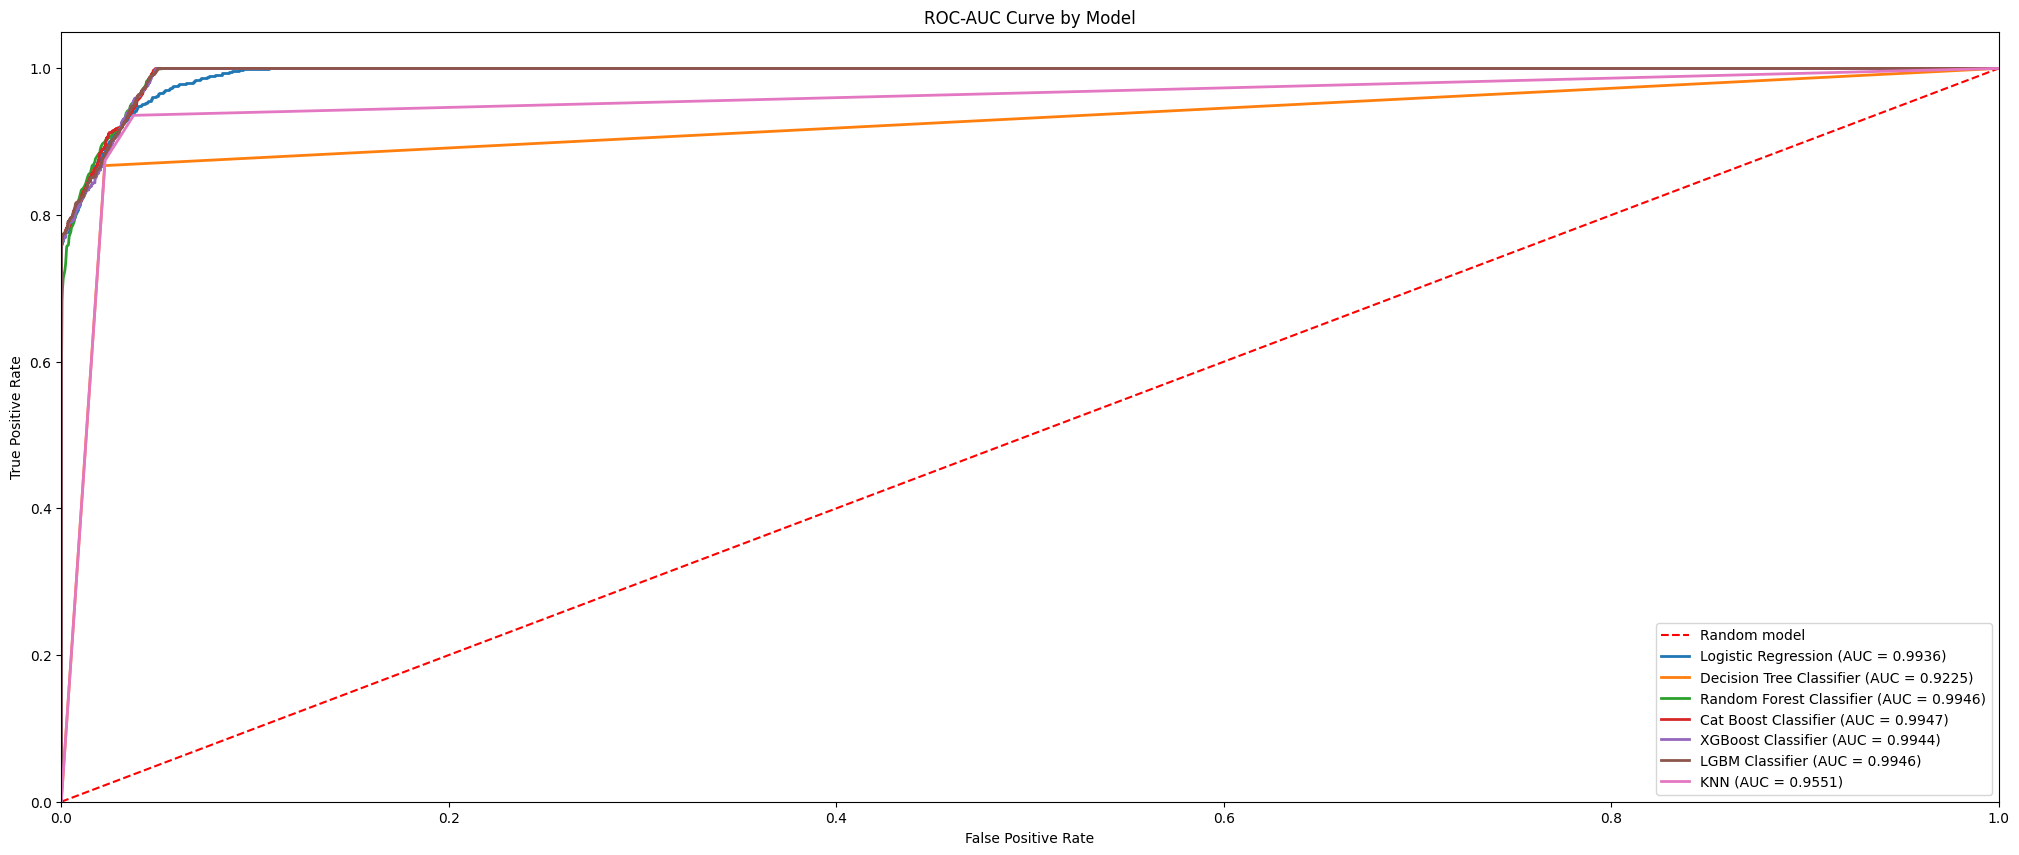

In [209]:
models ={
    'Logistic Regression': lr,
    'Decision Tree Classifier': dt,
    'Random Forest Classifier': rfc,
    'Cat Boost Classifier': cbc,
    'XGBoost Classifier': xgb,
    'LGBM Classifier': lgbm,
    'KNN': knn,
}

from sklearn.metrics import roc_curve, roc_auc_score

plt.figure(figsize=(25, 10))

# Plot the chance level line (random classifier)
plt.plot([0, 1], [0, 1], color='red', linestyle='--', label='Random model')

for name, model in models.items():
    # Get predicted probabilities for the positive class
    y_pred_proba = model.predict_proba(X_test)[:, 1]
    
    # Calculate ROC curve data: false positive rate (fpr) and true positive rate (tpr)
    fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
    
    # Calculate AUC score for a better label
    auc_score = roc_auc_score(y_test, y_pred_proba)
    
    # Plot the ROC curve
    plt.plot(fpr, tpr, lw=2, label=f'{name} (AUC = {auc_score:.4f})')

# Add labels, title, and legend
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC-AUC Curve by Model')
plt.legend(loc="lower right")
plt.show()